# The OPEC Announcement Effect — a quantitative teardown 🔬
### 107 hardcoded ministerial decision days · vol multiple with bootstrap CI + placebo · Brown-Forsythe + Welch spread tests · HAC drift regressions over 15 horizon×tape cells · the continuation rule's 2020 decomposition · a planted-effect machinery control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Vol_doubles%3F: Busted](https://img.shields.io/badge/Vol_doubles%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim splits into a **variance** claim ("vol doubles") and a **mean** claim ("the drift is tradable") — we test each with the appropriate inference and let the tape grade them separately.

> ⚠️ **Data note.** Event input = the frozen 107-meeting OPEC/OPEC+ table in [`data.py`](../opec_announcement_effect/data.py) (source-commented; JMMC/subgroup calls excluded by a pre-registered scope rule — conservative for the vol claim). Tapes: yfinance daily OHLC `CL=F` / `BZ=F` / `USO`, as-of **2026-06-30** (fingerprints `1a2103f8c32a` / `7e9543880619` / `6976f7deb0d1`). No survivorship — futures + a live ETF. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from opec_announcement_effect import data, strategy as st

AS_OF = "2026-06-30"
DATES = data.meeting_dates()
HAVE_REAL = data.have_real()
TAPES = data.load_real(asof=AS_OF) if HAVE_REAL else {}
print("real tapes cached:", HAVE_REAL, "| meetings:", len(DATES),
      f"({DATES.min().date()} -> {DATES.max().date()})")

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_meetings': 107, 'first': '2000-03-28', 'last': '2026-06-07', 'fp_cl': '1a2103f8c32a', 'fp_bz': '7e9543880619', 'fp_uso': '6976f7deb0d1', 'vol': {'CL': (105, 248.3, 177.1, 1.4, 1.15, 1.67, 3.07, 2.84, 1.23, 0.018, 1.45, 4.8), 'BZ': (68, 242.2, 158.0, 1.53, 1.21, 1.89, 3.01, 2.57, 2.12, 0.0, 1.52, 4.23), 'USO': (73, 242.1, 159.8, 1.52, 1.2, 1.85, 3.17, 3.09, 2.15, 0.0, 1.47, 3.64)}, 'drift': {'CL': [(0, -11.2, -0.3), (1, -50.3, -0.92), (2, -20.5, -0.16), (3, 16.6, 0.51), (5, -215.4, -0.89)], 'BZ': [(0, -0.1, -0.07), (1, -65.2, -1.15), (2, -47.2, -0.7), (3, -35.9, -0.44), (5, -50.0, -0.63)], 'USO': [(0, -14.2, -0.36), (1, -57.3, -0.9), (2, -39.3, -0.46), (3, -37.7, -0.34), (5, -31.5, -0.16)]}, 'cont': {'CL': (105, 365.0, 1.4, 61, 67.2, 1.29, 0.95, 1.27, 1.4), 'BZ': (68, 136.2, 1.69, 60, 111.5, 1.62, 0.87, 1.45, 0.58), 'USO': (73, 158.1, 2.2, 56, 70.7, 1.19, 0.68, 2.25, 1.91)}, 'cl_net': [(2.0, 361.0), (5.0, 355.0), (10.0, 345.0)], 'syn': [('null (x1)', 0.96, -0.51, 0.688, -6.3, -0.22), ('vol x2 planted', 1.92, 6.12, 0.0, -12.6, -0.26), ('x2 + drift +150', 2.01, 6.33, 0.0, 137.4, 3.22)]}


real tapes cached: True | meetings: 107 (2000-03-28 -> 2026-06-07)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | *Real on the vol:* multiple **1.40–1.53×** across tapes, Welch *t* = **+3.01 to +3.17**, range *t* to **+4.80**, placebo *p* ≤ 0.018. *None on the drift:* all 15 horizon×tape HAC *t* ∈ (−1.2, +0.6). |
| **Tradability** | `MIRAGE` | Day-0-sign continuation: best cell USO *t* = 2.20 → **1.19 ex-2020**; CL *t* = 1.40 at every cost level (net +345 bps/event at 10 bps one-way — never significant). |
| **Vol doubles?** | `BUSTED` | 95% bootstrap CI on the multiple: CL **1.15–1.67**, BZ 1.21–1.89, USO 1.20–1.85 — **2.0 outside all three**; a planted ×2 world reads Welch *t* ≈ 6 in this harness. |

> 💡 In plain words: the meeting days are genuinely loud (about half again as loud as normal), but nothing directional survives — and "doubles" fails its own number.

## 1 · The claim, steelmanned

Let $r_t$ be the daily close-to-close return and $E$ the set of day-0 sessions (first tradable session at-or-after each decision date). The folklore asserts:

- **H₁ (variance).** $\mathbb{E}[|r_t| \mid t \in E] \approx 2\, \mathbb{E}[|r_t| \mid t \notin E]$ — "vol doubles."
- **H₂ (mean).** Post-decision drift: $\mathbb{E}[\sum_{j=0}^{k} r_{e+j}] \neq 0$ for k = 0..5.
- **H₃ (continuation).** $\mathrm{sign}(r_{e})$ predicts $\sum_{j=1}^{5} r_{e+j}$ — the tradable version.

We find **H₁ half-supported** (elevated ~1.5×, *t* ≥ 3 — but the CI excludes 2.0), **H₂ rejected** (all |HAC *t*| < 1.2), **H₃ rejected** (never robustly significant; the one borderline cell is carried by the five 2020 meetings).

## 2 · So what? — the inference each claim needs

**Variance claims** need spread-robust tests: oil returns are fat-tailed and vol-clustered, so we use Welch on |r|, a Brown-Forsythe-style test (Welch on absolute deviations from group medians), a variance ratio, a **block-bootstrap CI on the multiple** (events i.i.d. — months apart; baseline in circular blocks of 10) and a seeded 2,000-draw random-calendar placebo.

**Mean claims** need HAC: event windows overlap their own autocorrelation, so the Signal-axis statistic is a Newey-West dummy regression of daily returns on the day-0..+k window (lags k+5), with the per-event one-sample *t* beside it.

**Tradability** needs an execution convention and a stress test: enter at the day-0 settle (the decision lands intraday, hours earlier — documented), lagged variant at close(+1); costs 2/5/10 bps one-way; and the sample re-run **without 2020**.

## 3 · How we'd know — the protocol

- **Events.** 107 decision days 2000-03-28 → 2026-06-07: every OPEC Conference 2000-2016, the production-setting consultations (2001/2003/Doha 2006), every ONOMM 2016-2026. Weekend meetings roll to the next session per asset; CL maps 105, BZ 68, USO 73 (tape starts differ).
- **Baseline.** All sessions further than ±5 from any day 0 (the halo keeps pre-positioning and echo days out of "normal").
- **Vol.** |r| and intraday range (H−L)/C₋₁, event vs baseline.
- **Drift.** Cumulative close(−1)→close(+k), k ∈ {0,1,2,3,5}.
- **Continuation.** sign(day-0) × fwd(+1..+5), gross and net.
- **Machinery control.** A deterministic world with meetings every ~63 sessions and a planted vol multiple / drift — the null must stay quiet, the planted folklore must fire.

## 4 · The teardown

### 4a · The vol multiple, its CI, and the placebo

Mean |r| on day 0 vs baseline, per tape — with the full-draw bootstrap CI (5,000 draws) and the 2,000-draw random-calendar placebo.

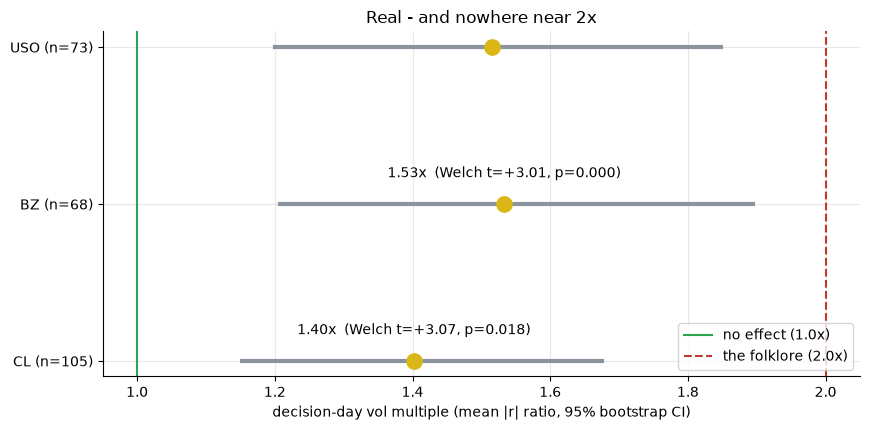

CL   n=105  x1.40 [1.15-1.67]  Welch t=+3.07  BF t=+2.84  placebo p=0.018
BZ   n= 68  x1.53 [1.21-1.89]  Welch t=+3.01  BF t=+2.57  placebo p=0.000
USO  n= 73  x1.52 [1.20-1.85]  Welch t=+3.17  BF t=+3.09  placebo p=0.000


In [2]:
keys = ['CL', 'BZ', 'USO']; tks = ['CL=F', 'BZ=F', 'USO']
if HAVE_REAL:
    V = {k: st.vol_stats(TAPES[tk], DATES, n_boot=5000, n_placebo=2000)
         for k, tk in zip(keys, tks)}
    rows = [(k, V[k]['n_events'], V[k]['vol_multiple'], V[k]['ci_lo'], V[k]['ci_hi'],
             V[k]['welch_t_abs'], V[k]['bf_t'], V[k]['p_placebo']) for k in keys]
else:
    rows = [(k, R['vol'][k][0], R['vol'][k][3], R['vol'][k][4], R['vol'][k][5],
             R['vol'][k][6], R['vol'][k][7], R['vol'][k][9]) for k in keys]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
y = np.arange(3)
for i, (k, n, m, lo, hi, w, bf, p) in enumerate(rows):
    ax.plot([lo, hi], [i, i], color=GREY, lw=3)
    ax.plot(m, i, 'o', color=AMBER, ms=11, zorder=3)
    ax.annotate(f'{m:.2f}x  (Welch t={w:+.2f}, p={p:.3f})', (m, i + .17), ha='center')
ax.axvline(1.0, color=GREEN, lw=1.5, label='no effect (1.0x)')
ax.axvline(2.0, color=RED, lw=1.5, ls='--', label='the folklore (2.0x)')
ax.set_yticks(y); ax.set_yticklabels([f'{k} (n={r[1]})' for k, r in zip(keys, rows)])
ax.set_xlabel('decision-day vol multiple (mean |r| ratio, 95% bootstrap CI)')
ax.set_title('Real - and nowhere near 2x'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()
for k, n, m, lo, hi, w, bf, p in rows:
    print(f'{k:4s} n={n:3d}  x{m:.2f} [{lo:.2f}-{hi:.2f}]  Welch t={w:+.2f}  BF t={bf:+.2f}  placebo p={p:.3f}')

> 💡 In plain words: the amber dots (the measured multiples, **1.40× / 1.53× / 1.52×**) sit far right of 1.0 — the effect is real (*t* ≥ 3, placebo *p* ≤ 0.018 — that's the Real half of the Signal stamp) — and every grey CI bar **stops short of the red 2.0 line**. The intraday range agrees: 1.45–1.52× at Welch *t* = +3.64 to +4.80.

### 4b · Drift — 15 cells of nothing

The Newey-West dummy-regression *t* for the cumulative drift close(−1)→close(+k), for every horizon and tape. The claim needs bars outside ±2.

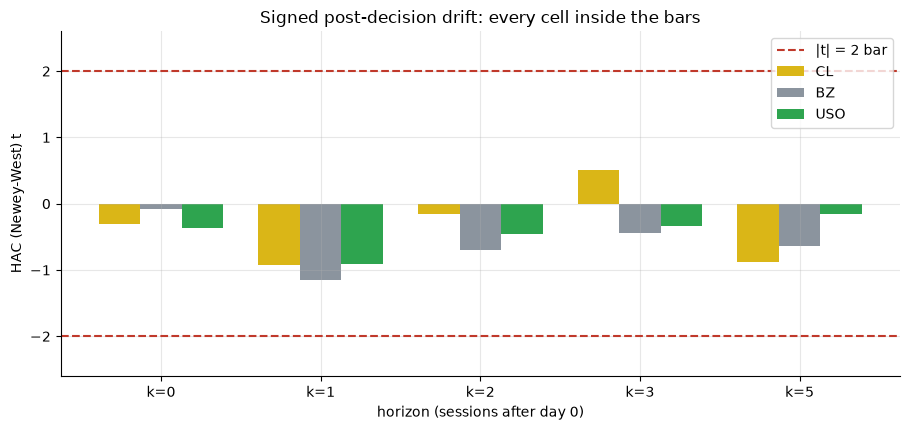

{'CL': [-0.3, -0.92, -0.16, 0.51, -0.89], 'BZ': [-0.07, -1.15, -0.7, -0.44, -0.63], 'USO': [-0.36, -0.9, -0.46, -0.34, -0.16]}


In [3]:
ks = [0, 1, 2, 3, 5]
if HAVE_REAL:
    T = {k: [d['hac_t'] for d in st.drift_stats(TAPES[tk], DATES)]
         for k, tk in zip(keys, tks)}
else:
    T = {k: [row[2] for row in R['drift'][k]] for k in keys}
x = np.arange(5); w = .26
fig, ax = plt.subplots(figsize=(9.2, 4.4))
for i, (k, c) in enumerate(zip(keys, [AMBER, GREY, GREEN])):
    ax.bar(x + (i - 1) * w, T[k], w, color=c, label=k)
ax.axhline(2, ls='--', c=RED); ax.axhline(-2, ls='--', c=RED, label='|t| = 2 bar')
ax.set_ylim(-2.6, 2.6); ax.set_xticks(x); ax.set_xticklabels([f'k={k}' for k in ks])
ax.set_xlabel('horizon (sessions after day 0)'); ax.set_ylabel('HAC (Newey-West) t')
ax.set_title('Signed post-decision drift: every cell inside the bars')
ax.legend(); plt.tight_layout(); plt.show()
print({k: [round(t, 2) for t in T[k]] for k in keys})

> 💡 In plain words: fifteen chances to find a drift, fifteen bars comfortably inside ±2 (the extremes are −1.15 and +0.51). The loud day 0 is **two-sided** — cuts rally, collapses crash — and the signed mean nets to zero. This is the None half of the Signal stamp.

### 4c · Continuation — the 2020 decomposition

sign(day-0) held to close(+5), gross per event, full sample vs ex-2020 vs the sub-periods. One borderline cell, and it doesn't survive.

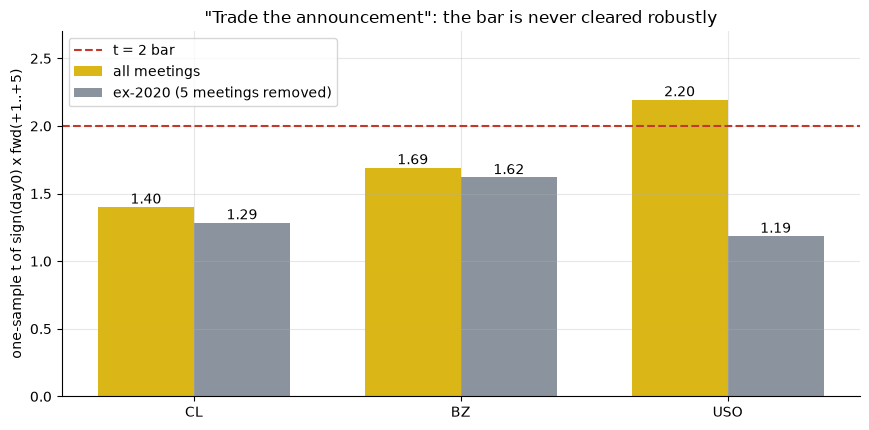

t all: [1.4, 1.69, 2.2]   t ex-2020: [1.29, 1.62, 1.19]


In [4]:
if HAVE_REAL:
    no20 = DATES[(DATES < '2020-01-01') | (DATES > '2020-12-31')]
    C = {k: (st.continuation_stats(TAPES[tk], DATES),
             st.continuation_stats(TAPES[tk], no20)) for k, tk in zip(keys, tks)}
    t_all = [C[k][0]['t'] for k in keys]; t_ex = [C[k][1]['t'] for k in keys]
else:
    t_all = [R['cont'][k][2] for k in keys]; t_ex = [R['cont'][k][5] for k in keys]
x = np.arange(3); w = .36
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(x - w/2, t_all, w, color=AMBER, label='all meetings')
ax.bar(x + w/2, t_ex, w, color=GREY, label='ex-2020 (5 meetings removed)')
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i in range(3):
    ax.annotate(f'{t_all[i]:.2f}', (i - w/2, t_all[i]), ha='center', va='bottom')
    ax.annotate(f'{t_ex[i]:.2f}', (i + w/2, t_ex[i]), ha='center', va='bottom')
ax.set_xticks(x); ax.set_xticklabels(keys); ax.set_ylabel('one-sample t of sign(day0) x fwd(+1..+5)')
ax.set_ylim(0, 2.7); ax.set_title('"Trade the announcement": the bar is never cleared robustly')
ax.legend(); plt.tight_layout(); plt.show()
print('t all:', [round(t, 2) for t in t_all], '  t ex-2020:', [round(t, 2) for t in t_ex])

> 💡 In plain words: only USO ever grazes the bar (*t* = 2.20) — and removing the five 2020 meetings drops it to **1.19**. Sub-periods: pre-2016 *t* = 0.95/0.87/0.68, 2016+ *t* = 1.27/1.45/2.25. The lagged (close(+1)) entry reads *t* = 1.40/0.58/1.91. Hit rates 56–61% — the kind that vanishes with five outliers.

**Costs are not the story.** CL gross +365.0 bps/event nets +361.0 / +355.0 / +345.0 at 2/5/10 bps one-way (~4 trades/yr, trivial capacity for retail) — the *t* never moves. The rule fails on **significance**, not friction — which is exactly what makes it a Mirage rather than Fragile.

### 4d · Machinery control — a world where the folklore is TRUE

Deterministic tape, meetings every ~63 sessions. Null (×1, no drift) must stay quiet; the folklore planted at full strength (vol ×2) and a planted +150 bps day-0 drift must light up. *(A machinery proof — never cited in support of a stamp.)*

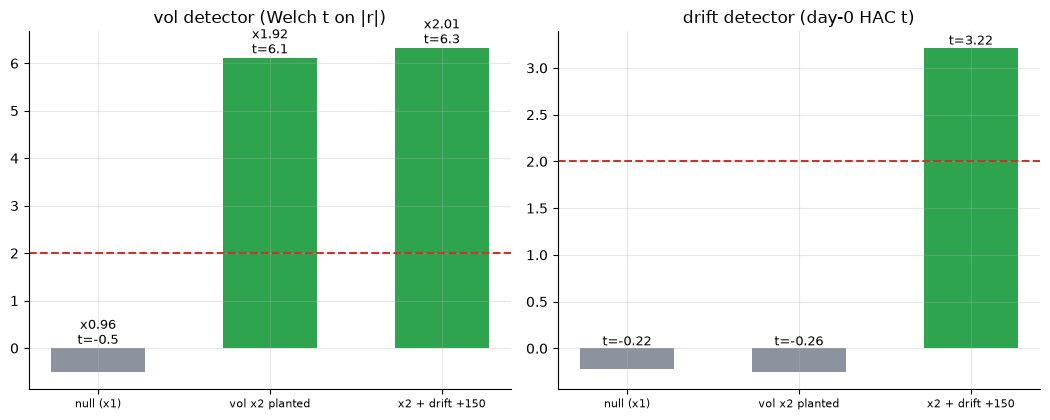

null (x1)          vol x0.96  welch t=-0.51  day-0 HAC t=-0.22
vol x2 planted     vol x1.92  welch t=+6.12  day-0 HAC t=-0.26
x2 + drift +150    vol x2.01  welch t=+6.33  day-0 HAC t=+3.22


In [5]:
res = []
for lab, vm, dr in [('null (x1)', 1.0, 0.0), ('vol x2 planted', 2.0, 0.0),
                    ('x2 + drift +150', 2.0, 0.015)]:
    px, dd = data.synthetic_world(vol_mult=vm, drift=dr, seed=606)
    v = st.vol_stats(px, dd, n_boot=500, n_placebo=300)
    d0 = st.drift_stats(px, dd, horizons=(0,))[0]
    res.append((lab, v['vol_multiple'], v['welch_t_abs'], d0['hac_t']))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
labs = [r[0] for r in res]
a1.bar(labs, [r[2] for r in res], color=[GREY, GREEN, GREEN], width=.55)
a1.axhline(2, ls='--', c=RED); a1.set_title('vol detector (Welch t on |r|)')
for i, r in enumerate(res): a1.annotate(f'x{r[1]:.2f}\nt={r[2]:.1f}', (i, max(r[2], 0)), ha='center', va='bottom', fontsize=9)
a2.bar(labs, [r[3] for r in res], color=[GREY, GREY, GREEN], width=.55)
a2.axhline(2, ls='--', c=RED); a2.set_title('drift detector (day-0 HAC t)')
for i, r in enumerate(res): a2.annotate(f't={r[3]:.2f}', (i, max(r[3], 0)), ha='center', va='bottom', fontsize=9)
for a in (a1, a2): a.tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.show()
for r in res: print(f'{r[0]:18s} vol x{r[1]:.2f}  welch t={r[2]:+.2f}  day-0 HAC t={r[3]:+.2f}')

> 💡 In plain words: in a world where vol truly doubles, this harness reads **×1.92 at Welch *t* ≈ 6** — and a planted +150 bps drift reads HAC *t* = 3.22. On the null it stays silent (×0.96, *t* = -0.51). So the real tape's ×1.4–1.5 at *t* ≈ 3 and its 15 dead drift cells are measurements, not blind spots.

## 5 · The verdict

- **Signal `MIXED`** — *Real on the vol:* multiple **1.40×/1.53×/1.52×** (CL/BZ/USO), Welch *t* = **+3.07/+3.01/+3.17**, BF *t* +2.57 to +3.09, range *t* to +4.80, placebo *p* ≤ 0.018 — clears *t* ≥ 2 on the real tape. *None on the drift:* all 15 horizon×tape HAC *t* inside (−1.2, +0.6).
- **Tradability `MIRAGE`** — nothing directional to deploy: drift ≈ 0 at every horizon; continuation never robustly clears the bar (best cell 2.20 → 1.19 ex-2020) and costs are irrelevant to that failure; the vol premium is precisely when optionality is already expensive.
- **Vol doubles? `BUSTED`** — 1.4–1.5× with 95% CIs of 1.15–1.67 / 1.21–1.89 / 1.20–1.85: 2.0 excluded everywhere, and the planted-×2 control proves the harness had the power to see a doubling.

## 6 · Going further

- **Decision asymmetry.** The literature (Loutia et al. 2016; Demirer-Kutan 2010) finds cuts ≠ raises ≠ holds. The frozen table carries per-meeting labels — sort the drift by decision type and the two-sidedness becomes visible instead of averaged away.
- **The excluded events are the sharp ones.** JMMC and V8-subgroup surprises (3 Apr 2023, the 2025 V8 calls) were excluded by the scope rule; adding them would likely *raise* the vol multiple — the scope choice is conservative, and the doubling still fails.
- **Options, not futures.** A 1.5× realized-vol day is a straddle question: is the OPEC-day variance premium over- or under-priced in CL weeklies? That's a different study — this one only establishes the realized side.

*The reproducible core is offline and deterministic; siblings: [313-geopolitical-shock](../../313-geopolitical-shock/) (unscheduled shocks), [226-crude-seasonality](../../226-crude-seasonality/) (calendar time), [602-macro-announcement-premium](../../602-macro-announcement-premium/) (the macro cousin). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*